# The Chart Detective: Development and Evaluation of an EMA-Based Trading Strategy

**Primary Stock:** BAJFINANCE.NS  
**Initial Portfolio Capital:** ₹100,000  

## Objective

This notebook develops and evaluates an equity trading strategy based on Exponential Moving Average (EMA) crossovers.

The analysis begins with a baseline EMA crossover strategy and progressively evaluates possible improvements using:

1. RSI momentum confirmation.
2. A long-term trend filter.
3. RSI threshold sensitivity analysis.
4. Trailing stop-loss exit mechanisms.
5. Validation across multiple stocks.

The strategies are evaluated using total return, number of trades, win rate, maximum drawdown and Sharpe ratio.

## Strategy Design and Rules

The final strategy is based on a 20-day and 50-day EMA crossover with RSI momentum confirmation and a trailing stop for risk management.

### Entry Rule

A long position is entered when both of the following conditions are satisfied:

1. The 20-day EMA crosses above the 50-day EMA.
2. The 14-day RSI is greater than 50.

### Exit Rule

The position is exited when either:

1. The 20-day EMA crosses below the 50-day EMA, or
2. The closing price falls 7.5% below the highest closing price reached since entering the position.

### Risk Management

The trailing stop limits the downside from a reversal after a position has moved in the trader's favour. The stop moves upward as a new highest price is reached but does not move downward.

# 1. Data Collection and Preparation

## Historical Data

Historical daily price data is downloaded using Yahoo Finance.

Additional historical observations are included before the main backtest period so that the technical indicators have sufficient data to stabilise before the strategy evaluation begins.

The primary stock used for initial strategy development is BAJFINANCE.NS.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os


In [2]:
ticker = "BAJFINANCE.NS"

start_date = "2025-08-25"
end_date = "2026-08-24"

print("Instrument:", ticker)
print("Backtest period:", start_date, "to", end_date)

Instrument: BAJFINANCE.NS
Backtest period: 2025-08-25 to 2026-08-24


In [3]:
full_data = yf.download(
    ticker,
    period="2y",
    interval="1d",
    auto_adjust=False,
    progress=False
)

# Fix column structure if yfinance returns MultiIndex columns
if isinstance(full_data.columns, pd.MultiIndex):
    full_data.columns = full_data.columns.get_level_values(0)

# Remove missing values
full_data = full_data.dropna()

print("Historical data start:", full_data.index.min())
print("Historical data end:", full_data.index.max())
print("Number of trading days:", len(full_data))

Historical data start: 2024-09-03 00:00:00
Historical data end: 2026-09-03 00:00:00
Number of trading days: 501


# 2. Technical Indicator Calculation

The strategy uses the following technical indicators:

- **20-day EMA:** Represents the shorter-term price trend.
- **50-day EMA:** Represents the medium-term price trend.
- **14-day RSI:** Measures recent price momentum and is used as a confirmation filter.

The EMA crossover provides the primary trading signal, while RSI is later introduced to confirm positive momentum before entering a trade.

In [4]:
# =========================
# 20-Day EMA
# =========================

full_data["EMA20"] = full_data["Close"].ewm(
    span=20,
    adjust=False
).mean()


# =========================
# 50-Day EMA
# =========================

full_data["EMA50"] = full_data["Close"].ewm(
    span=50,
    adjust=False
).mean()


# =========================
# 200-Day EMA
# Long-term trend filter
# =========================

full_data["EMA200"] = full_data["Close"].ewm(
    span=200,
    adjust=False
).mean()


# =========================
# RSI (14-Day)
# =========================

delta = full_data["Close"].diff()

gain = delta.where(
    delta > 0,
    0
)

loss = -delta.where(
    delta < 0,
    0
)

avg_gain = gain.rolling(
    window=14
).mean()

avg_loss = loss.rolling(
    window=14
).mean()

rs = avg_gain / avg_loss

full_data["RSI"] = 100 - (
    100 / (1 + rs)
)


# =========================
# Create backtest dataset
# =========================

data = full_data.loc[
    start_date:end_date
].copy()


print("Backtest start:", data.index.min())
print("Backtest end:", data.index.max())
print("Trading days:", len(data))

print("\nColumns available:")
print(data.columns.tolist())

Backtest start: 2025-08-25 00:00:00
Backtest end: 2026-08-24 00:00:00
Trading days: 250

Columns available:
['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'EMA20', 'EMA50', 'EMA200', 'RSI']


# 3. Baseline Strategy: EMA Crossover

The baseline strategy uses a crossover between the 20-day and 50-day Exponential Moving Averages.

## Entry Rule

A long position is entered when the 20-day EMA crosses above the 50-day EMA.

## Exit Rule

The position is exited when the 20-day EMA crosses below the 50-day EMA.

This baseline strategy is used as the benchmark against which all subsequent modifications are evaluated.

In [5]:
# Previous day's EMA values

data["Prev_EMA20"] = data["EMA20"].shift(1)

data["Prev_EMA50"] = data["EMA50"].shift(1)


# =========================
# BUY SIGNAL
# =========================

data["Bullish_Crossover"] = (
    (data["EMA20"] > data["EMA50"]) &
    (data["Prev_EMA20"] <= data["Prev_EMA50"])
)


# =========================
# SELL SIGNAL
# =========================

data["Bearish_Crossover"] = (
    (data["EMA20"] < data["EMA50"]) &
    (data["Prev_EMA20"] >= data["Prev_EMA50"])
)


print(
    "Bullish Crossovers:",
    data["Bullish_Crossover"].sum()
)

print(
    "Bearish Crossovers:",
    data["Bearish_Crossover"].sum()
)

Bullish Crossovers: 5
Bearish Crossovers: 4


In [6]:
crossovers = data[
    data["Bullish_Crossover"] |
    data["Bearish_Crossover"]
]

crossovers[
    [
        "Close",
        "EMA20",
        "EMA50",
        "Bullish_Crossover",
        "Bearish_Crossover"
    ]
]

Price,Close,EMA20,EMA50,Bullish_Crossover,Bearish_Crossover
Date,,,,,
2025-09-09,948.400024,906.774210,904.814484,True,False
2025-12-19,1008.299988,1014.792881,1015.069661,False,True
2026-02-18,1023.799988,980.907272,979.762401,True,False
2026-03-09,938.049988,981.110658,982.809776,False,True
2026-05-05,958.599976,921.601830,921.287995,True,False
2026-05-21,907.650024,922.696634,923.166008,False,True
2026-05-25,941.900024,923.995885,923.651398,True,False
2026-06-01,889.049988,920.769229,922.465281,False,True
2026-06-18,958.849976,918.149936,917.472695,True,False


# 4. Strategy Improvement: RSI Momentum Confirmation

The baseline EMA crossover strategy can generate signals during periods with weak or uncertain momentum.

To improve the quality of entry signals, a 14-day RSI confirmation filter is added.

## Strategy B Entry Rule

A long position is entered only when:

- The 20-day EMA crosses above the 50-day EMA, and
- The RSI is greater than 50.

## Exit Rule

The position is exited when the 20-day EMA crosses below the 50-day EMA.

The objective of this modification is to avoid entering trades when the EMA crossover occurs without sufficient positive momentum.

In [7]:
# ==========================================
# STRATEGY B
# EMA Crossover + RSI Momentum Confirmation
# ==========================================


data["Signal_B"] = (
    data["Bullish_Crossover"] &
    (data["RSI"] > 50)
)


print(
    "Strategy B Buy Signals:",
    data["Signal_B"].sum()
)

Strategy B Buy Signals: 4


# 5. Additional inducator: Long-Term Trend Filter

A further experiment adds a long-term trend confirmation condition to the EMA and RSI strategy.

The purpose of this test is to determine whether restricting trades according to a broader trend direction improves the performance of the strategy.

This strategy is retained as an additional experimental comparison. Its results are later evaluated against the baseline EMA strategy and the EMA + RSI strategy.

In [8]:
# ==========================================
# STRATEGY C
# EMA + RSI + Long-Term Trend Filter
# ==========================================


data["Signal_C"] = (
    data["Bullish_Crossover"] &
    (data["RSI"] > 50) &
    (data["Close"] > data["EMA200"])
)


print(
    "Strategy C Buy Signals:",
    data["Signal_C"].sum()
)

Strategy C Buy Signals: 4


# 6. Trading Signal Comparison

Before backtesting, the number of trading signals generated by each strategy is compared.

The strategies compared are:

- **Strategy A:** EMA crossover only.
- **Strategy B:** EMA crossover + RSI momentum confirmation.
- **Strategy C:** EMA crossover + RSI + long-term trend filter.

This comparison helps determine whether the additional filters remove or modify EMA crossover signals before portfolio performance is evaluated.

In [9]:
print("STRATEGY SIGNAL COMPARISON")
print("-" * 35)

print(
    "Strategy A - EMA Only:",
    data["Bullish_Crossover"].sum()
)

print(
    "Strategy B - EMA + RSI:",
    data["Signal_B"].sum()
)

print(
    "Strategy C - EMA + RSI + Trend:",
    data["Signal_C"].sum()
)

STRATEGY SIGNAL COMPARISON
-----------------------------------
Strategy A - EMA Only: 5
Strategy B - EMA + RSI: 4
Strategy C - EMA + RSI + Trend: 4


# 7. Backtesting Methodology

Each strategy is evaluated using the same backtesting framework.

## Assumptions

- Initial portfolio capital is ₹100,000.
- Available capital is invested when a valid buy signal occurs.
- No leverage is used.
- Positions are exited according to the strategy's exit conditions.
- Portfolio value is tracked throughout the backtest period.

## Performance Metrics

The strategies are evaluated using:

- Final Portfolio Value
- Total Return
- Number of Trades
- Win Rate
- Maximum Drawdown
- Sharpe Ratio

Using the same methodology for every strategy allows their performance to be compared consistently.

In [10]:
def backtest_strategy(data, buy_signal_column, initial_capital=100000):
    
    # Create a copy so the original data is not modified
    bt = data.copy()
    
    # Starting values
    cash = initial_capital
    shares = 0
    
    # Track portfolio value
    portfolio_values = []
    
    # Track completed trades
    trades = []
    
    # Track current entry
    entry_price = None
    entry_date = None
    
    
    # Loop through every trading day
    for date, row in bt.iterrows():
        
        close_price = float(row["Close"])
        
        
        # ==========================
        # BUY CONDITION
        # ==========================
        
        if shares == 0 and row[buy_signal_column]:
            
            # Invest all available cash
            shares = cash / close_price
            
            entry_price = close_price
            entry_date = date
            
            cash = 0
        
        
        # ==========================
        # SELL CONDITION
        # ==========================
        
        elif shares > 0 and row["Bearish_Crossover"]:
            
            # Calculate sale value
            cash = shares * close_price
            
            # Calculate trade return
            trade_return = (
                (close_price - entry_price)
                / entry_price
            ) * 100
            
            
            # Save completed trade
            trades.append({
                "Entry Date": entry_date,
                "Exit Date": date,
                "Entry Price": entry_price,
                "Exit Price": close_price,
                "Return (%)": trade_return
            })
            
            
            # Reset position
            shares = 0
            entry_price = None
            entry_date = None
        
        
        # ==========================
        # PORTFOLIO VALUE
        # ==========================
        
        if shares > 0:
            portfolio_value = shares * close_price
        else:
            portfolio_value = cash
        
        portfolio_values.append(portfolio_value)
    
    
    # ==========================
    # HANDLE OPEN POSITION
    # ==========================
    
    if shares > 0:
        
        final_price = float(bt["Close"].iloc[-1])
        
        cash = shares * final_price
        
        trade_return = (
            (final_price - entry_price)
            / entry_price
        ) * 100
        
        
        trades.append({
            "Entry Date": entry_date,
            "Exit Date": bt.index[-1],
            "Entry Price": entry_price,
            "Exit Price": final_price,
            "Return (%)": trade_return
        })
    
    
    # Add portfolio values to dataframe
    bt["Portfolio_Value"] = portfolio_values
    
    
    # Convert trades to dataframe
    trades_df = pd.DataFrame(trades)
    
    
    # ==========================
    # PERFORMANCE METRICS
    # ==========================
    
    final_value = bt["Portfolio_Value"].iloc[-1]
    
    total_return = (
        (final_value - initial_capital)
        / initial_capital
    ) * 100
    
    
    # Number of completed trades
    number_of_trades = len(trades)
    
    
    # Win rate
    if number_of_trades > 0:
        
        winning_trades = (
            trades_df["Return (%)"] > 0
        ).sum()
        
        win_rate = (
            winning_trades / number_of_trades
        ) * 100
    
    else:
        win_rate = 0
    
    
    # ==========================
    # MAXIMUM DRAWDOWN
    # ==========================
    
    running_max = bt["Portfolio_Value"].cummax()
    
    drawdown = (
        bt["Portfolio_Value"] - running_max
    ) / running_max
    
    max_drawdown = drawdown.min() * 100
    
    
    # ==========================
    # DAILY RETURNS + SHARPE
    # ==========================
    
    daily_returns = (
        bt["Portfolio_Value"]
        .pct_change()
        .dropna()
    )
    
    
    if daily_returns.std() != 0:
        
        sharpe_ratio = (
            daily_returns.mean()
            / daily_returns.std()
        ) * (252 ** 0.5)
    
    else:
        sharpe_ratio = 0
    
    
    # ==========================
    # RESULTS
    # ==========================
    
    results = {
        "Final Portfolio Value": final_value,
        "Total Return (%)": total_return,
        "Number of Trades": number_of_trades,
        "Win Rate (%)": win_rate,
        "Maximum Drawdown (%)": max_drawdown,
        "Sharpe Ratio": sharpe_ratio
    }
    
    
    return results, bt, trades_df

# 8. Strategy A Results: Baseline EMA Crossover

The baseline EMA crossover strategy is backtested using the methodology defined above.

These results provide the benchmark against which the modified strategies are evaluated.

In [11]:
results_A, bt_A, trades_A = backtest_strategy(
    data=data,
    buy_signal_column="Bullish_Crossover"
)

print("STRATEGY A — EMA CROSSOVER ONLY")
print("-" * 40)

for key, value in results_A.items():
    print(key, ":", value)

STRATEGY A — EMA CROSSOVER ONLY
----------------------------------------
Final Portfolio Value : 97785.95725897174
Total Return (%) : -2.214042741028257
Number of Trades : 5
Win Rate (%) : 40.0
Maximum Drawdown (%) : -24.538378686199934
Sharpe Ratio : -0.0015324445179522586


# 9. Strategy B Results: EMA Crossover + RSI

The EMA crossover strategy with RSI momentum confirmation is now backtested using the same methodology and initial capital as the baseline strategy.

The objective is to determine whether requiring RSI to be greater than 50 improves the quality of the EMA crossover entries and the overall risk-return performance.

In [12]:
results_B, bt_B, trades_B = backtest_strategy(
    data=data,
    buy_signal_column="Signal_B"
)

print("STRATEGY B — EMA + RSI")
print("-" * 40)

for key, value in results_B.items():
    print(key, ":", value)

STRATEGY B — EMA + RSI
----------------------------------------
Final Portfolio Value : 103598.89409393498
Total Return (%) : 3.598894093934985
Number of Trades : 4
Win Rate (%) : 50.0
Maximum Drawdown (%) : -21.065464616089706
Sharpe Ratio : 0.2753883933340265


# 10. Strategy C Results: EMA + RSI + Trend Filter

The additional long-term trend filter is evaluated using the same backtesting methodology.

This experiment is included to determine whether the extra trend condition changes the trading signals or improves performance compared with the EMA + RSI strategy.

In [13]:
results_C, bt_C, trades_C = backtest_strategy(
    data=data,
    buy_signal_column="Signal_C"
)

print("STRATEGY C — EMA + RSI + TREND FILTER")
print("-" * 40)

for key, value in results_C.items():
    print(key, ":", value)

STRATEGY C — EMA + RSI + TREND FILTER
----------------------------------------
Final Portfolio Value : 103598.89409393498
Total Return (%) : 3.598894093934985
Number of Trades : 4
Win Rate (%) : 50.0
Maximum Drawdown (%) : -21.065464616089706
Sharpe Ratio : 0.2753883933340265


# 11. Strategy Comparison and Visual Analysis

The performance of the baseline and modified strategies is compared using both numerical performance metrics and portfolio value over time.

The objective is to examine whether the additional filters improve:

- Total return.
- Trade quality.
- Maximum drawdown.
- Risk-adjusted performance.

The comparison provides the basis for deciding which modifications should be tested further.

In [14]:
comparison = pd.DataFrame(
    [
        results_A,
        results_B,
        results_C
    ],
    index=[
        "Strategy A - EMA Only",
        "Strategy B - EMA + RSI",
        "Strategy C - EMA + RSI + Trend"
    ]
)

comparison

,Final Portfolio Value,Total Return (%),Number of Trades,Win Rate (%),Maximum Drawdown (%),Sharpe Ratio
Strategy A - EMA Only,97785.957259,-2.214043,5,40.0,-24.538379,-0.001532
Strategy B - EMA + RSI,103598.894094,3.598894,4,50.0,-21.065465,0.275388
Strategy C - EMA + RSI + Trend,103598.894094,3.598894,4,50.0,-21.065465,0.275388


In [15]:
comparison_rounded = comparison.round(2)

comparison_rounded

,Final Portfolio Value,Total Return (%),Number of Trades,Win Rate (%),Maximum Drawdown (%),Sharpe Ratio
Strategy A - EMA Only,97785.96,-2.21,5,40.0,-24.54,-0.00
Strategy B - EMA + RSI,103598.89,3.60,4,50.0,-21.07,0.28
Strategy C - EMA + RSI + Trend,103598.89,3.60,4,50.0,-21.07,0.28


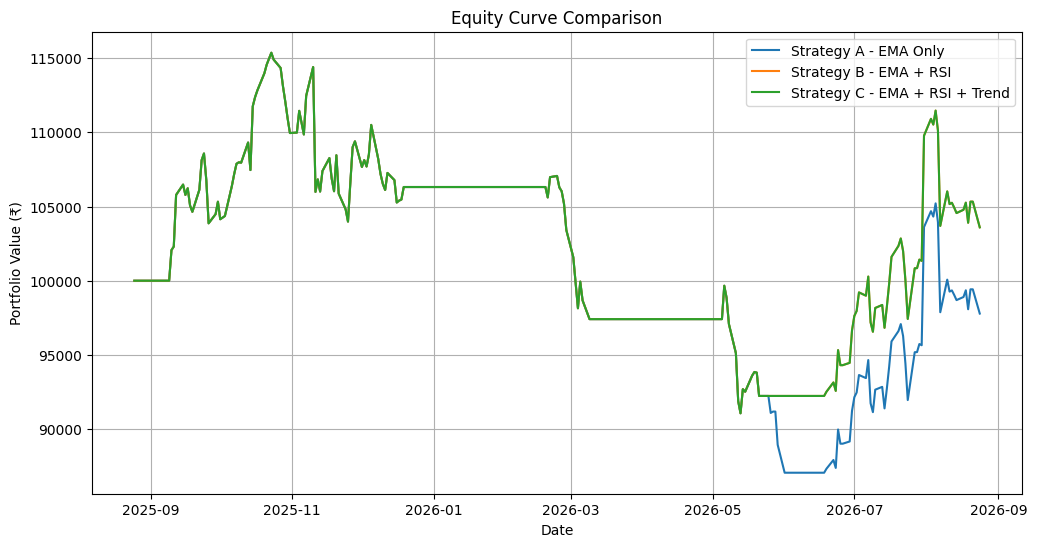

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    bt_A.index,
    bt_A["Portfolio_Value"],
    label="Strategy A - EMA Only"
)

plt.plot(
    bt_B.index,
    bt_B["Portfolio_Value"],
    label="Strategy B - EMA + RSI"
)

plt.plot(
    bt_C.index,
    bt_C["Portfolio_Value"],
    label="Strategy C - EMA + RSI + Trend"
)

plt.title("Equity Curve Comparison")

plt.xlabel("Date")

plt.ylabel("Portfolio Value (₹)")

plt.legend()

plt.grid(True)

plt.show()

# 12. RSI Threshold Sensitivity Analysis

The RSI > 50 condition is tested for robustness by comparing it with nearby threshold values.

The following thresholds are evaluated:

- RSI > 45
- RSI > 50
- RSI > 55

The EMA crossover rules and the backtesting methodology remain unchanged.

This analysis examines whether the improvement observed with RSI confirmation depends heavily on one specific threshold.

In [17]:
# ==========================================
# RSI THRESHOLD SENSITIVITY TEST
# ==========================================

data["Signal_RSI_45"] = (
    data["Bullish_Crossover"] &
    (data["RSI"] > 45)
)

data["Signal_RSI_50"] = (
    data["Bullish_Crossover"] &
    (data["RSI"] > 50)
)

data["Signal_RSI_55"] = (
    data["Bullish_Crossover"] &
    (data["RSI"] > 55)
)


print("RSI > 45 signals:", data["Signal_RSI_45"].sum())
print("RSI > 50 signals:", data["Signal_RSI_50"].sum())
print("RSI > 55 signals:", data["Signal_RSI_55"].sum())

RSI > 45 signals: 5
RSI > 50 signals: 4
RSI > 55 signals: 4


In [18]:
# ==========================================
# BACKTEST RSI THRESHOLD VARIATIONS
# ==========================================

results_RSI_45, bt_RSI_45, trades_RSI_45 = backtest_strategy(
    data=data,
    buy_signal_column="Signal_RSI_45"
)


results_RSI_50, bt_RSI_50, trades_RSI_50 = backtest_strategy(
    data=data,
    buy_signal_column="Signal_RSI_50"
)


results_RSI_55, bt_RSI_55, trades_RSI_55 = backtest_strategy(
    data=data,
    buy_signal_column="Signal_RSI_55"
)


print("All RSI threshold strategies backtested successfully.")

All RSI threshold strategies backtested successfully.


In [19]:
# ==========================================
# RSI THRESHOLD ROBUSTNESS COMPARISON
# ==========================================

rsi_comparison = pd.DataFrame(
    [
        results_RSI_45,
        results_RSI_50,
        results_RSI_55
    ],
    index=[
        "EMA + RSI > 45",
        "EMA + RSI > 50",
        "EMA + RSI > 55"
    ]
)

rsi_comparison.round(2)

,Final Portfolio Value,Total Return (%),Number of Trades,Win Rate (%),Maximum Drawdown (%),Sharpe Ratio
EMA + RSI > 45,97785.96,-2.21,5,40.0,-24.54,-0.00
EMA + RSI > 50,103598.89,3.60,4,50.0,-21.07,0.28
EMA + RSI > 55,103598.89,3.60,4,50.0,-21.07,0.28


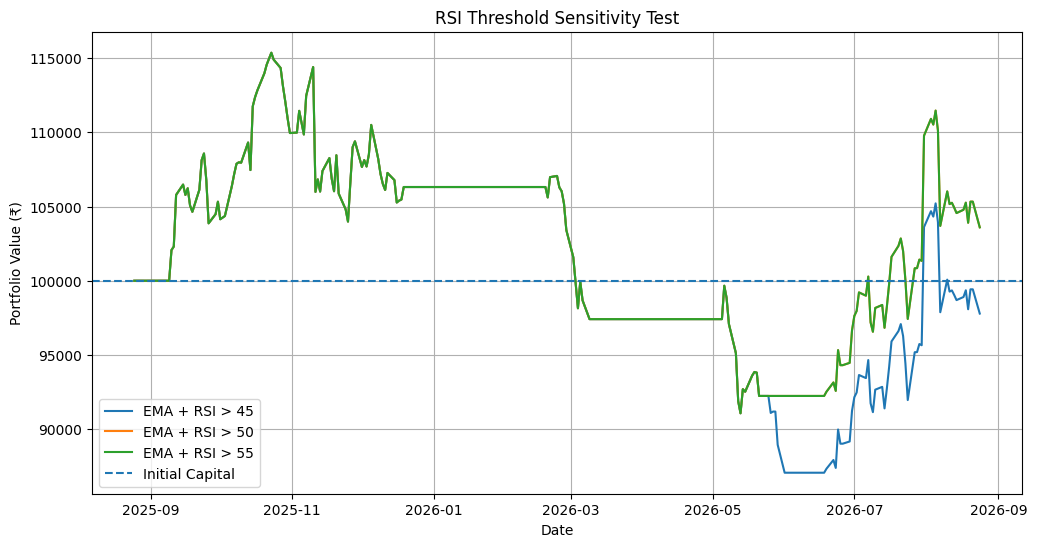

In [20]:
plt.figure(figsize=(12, 6))

plt.plot(
    bt_RSI_45.index,
    bt_RSI_45["Portfolio_Value"],
    label="EMA + RSI > 45"
)

plt.plot(
    bt_RSI_50.index,
    bt_RSI_50["Portfolio_Value"],
    label="EMA + RSI > 50"
)

plt.plot(
    bt_RSI_55.index,
    bt_RSI_55["Portfolio_Value"],
    label="EMA + RSI > 55"
)

plt.axhline(
    y=100000,
    linestyle="--",
    label="Initial Capital"
)

plt.title("RSI Threshold Sensitivity Test")

plt.xlabel("Date")

plt.ylabel("Portfolio Value (₹)")

plt.legend()

plt.grid(True)

plt.show()

### Interpretation

The RSI > 45 threshold allowed an additional EMA crossover signal and produced weaker performance.

The RSI > 50 and RSI > 55 thresholds produced identical results during the selected backtest period.

This suggests that the improvement was associated with requiring stronger positive momentum rather than proving that RSI = 50 is uniquely optimal. The results should therefore be interpreted as a sensitivity test rather than parameter optimisation.

# 13. Exit Strategy Improvement: Trailing Stop

EMA crossovers are lagging indicators. A bearish crossover may occur after a position has already experienced a significant price reversal.

To improve the exit mechanism, a trailing stop is introduced as an additional exit condition.

## Entry Rule

A long position is entered when:

- The 20-day EMA crosses above the 50-day EMA, and
- RSI is greater than 50.

## Exit Rule

The position is exited when either:

- The 20-day EMA crosses below the 50-day EMA, or
- The closing price falls by a specified percentage from the highest price reached since entry.

The trailing stop moves upward as the price reaches new highs but does not move downward.

In [21]:
def backtest_trailing_stop(
    data,
    buy_signal_column,
    initial_capital=100000,
    trailing_stop_pct=0.10
):
    
    # Copy the data
    bt = data.copy()
    
    # Starting portfolio
    cash = initial_capital
    shares = 0
    
    # Track portfolio values
    portfolio_values = []
    
    # Track completed trades
    trades = []
    
    # Entry information
    entry_price = None
    entry_date = None
    
    # Highest price reached while in the position
    highest_price = None
    
    
    # Loop through each trading day
    for date, row in bt.iterrows():
        
        close_price = float(row["Close"])
        
        
        # ==================================
        # BUY
        # ==================================
        
        if shares == 0 and row[buy_signal_column]:
            
            # Invest all available capital
            shares = cash / close_price
            
            cash = 0
            
            # Store entry details
            entry_price = close_price
            entry_date = date
            
            # Initial highest price
            highest_price = close_price
        
        
        # ==================================
        # UPDATE HIGHEST PRICE
        # ==================================
        
        elif shares > 0:
            
            highest_price = max(
                highest_price,
                close_price
            )
        
        
        # ==================================
        # SELL CONDITIONS
        # ==================================
        
        if shares > 0:
            
            # Trailing stop price
            trailing_stop_price = (
                highest_price *
                (1 - trailing_stop_pct)
            )
            
            
            # Sell if bearish EMA crossover
            ema_exit = row["Bearish_Crossover"]
            
            
            # Sell if price drops below trailing stop
            trailing_stop_exit = (
                close_price <= trailing_stop_price
            )
            
            
            if ema_exit or trailing_stop_exit:
                
                # Sell shares
                cash = shares * close_price
                
                
                # Calculate return
                trade_return = (
                    (close_price - entry_price)
                    / entry_price
                ) * 100
                
                
                # Record the trade
                trades.append({
                    "Entry Date": entry_date,
                    "Exit Date": date,
                    "Entry Price": entry_price,
                    "Exit Price": close_price,
                    "Highest Price": highest_price,
                    "Return (%)": trade_return,
                    "Exit Reason": (
                        "Trailing Stop"
                        if trailing_stop_exit
                        else "Bearish EMA Crossover"
                    )
                })
                
                
                # Reset position
                shares = 0
                entry_price = None
                entry_date = None
                highest_price = None
        
        
        # ==================================
        # PORTFOLIO VALUE
        # ==================================
        
        if shares > 0:
            portfolio_value = shares * close_price
        else:
            portfolio_value = cash
        
        portfolio_values.append(portfolio_value)
    
    
    # ==================================
    # CLOSE OPEN POSITION AT END
    # ==================================
    
    if shares > 0:
        
        final_price = float(bt["Close"].iloc[-1])
        
        cash = shares * final_price
        
        trade_return = (
            (final_price - entry_price)
            / entry_price
        ) * 100
        
        
        trades.append({
            "Entry Date": entry_date,
            "Exit Date": bt.index[-1],
            "Entry Price": entry_price,
            "Exit Price": final_price,
            "Highest Price": highest_price,
            "Return (%)": trade_return,
            "Exit Reason": "End of Backtest"
        })
    
    
    # Add portfolio values
    bt["Portfolio_Value"] = portfolio_values
    
    
    # Create trades dataframe
    trades_df = pd.DataFrame(trades)
    
    
    # ==================================
    # PERFORMANCE METRICS
    # ==================================
    
    final_value = bt["Portfolio_Value"].iloc[-1]
    
    total_return = (
        (final_value - initial_capital)
        / initial_capital
    ) * 100
    
    
    number_of_trades = len(trades)
    
    
    # Win rate
    if number_of_trades > 0:
        
        winning_trades = (
            trades_df["Return (%)"] > 0
        ).sum()
        
        win_rate = (
            winning_trades /
            number_of_trades
        ) * 100
    
    else:
        win_rate = 0
    
    
    # Maximum drawdown
    running_max = bt["Portfolio_Value"].cummax()
    
    drawdown = (
        bt["Portfolio_Value"] -
        running_max
    ) / running_max
    
    max_drawdown = drawdown.min() * 100
    
    
    # Sharpe Ratio
    daily_returns = (
        bt["Portfolio_Value"]
        .pct_change()
        .dropna()
    )
    
    
    if daily_returns.std() != 0:
        
        sharpe_ratio = (
            daily_returns.mean()
            /
            daily_returns.std()
        ) * (252 ** 0.5)
    
    else:
        sharpe_ratio = 0
    
    
    results = {
        "Final Portfolio Value": final_value,
        "Total Return (%)": total_return,
        "Number of Trades": number_of_trades,
        "Win Rate (%)": win_rate,
        "Maximum Drawdown (%)": max_drawdown,
        "Sharpe Ratio": sharpe_ratio
    }
    
    
    return results, bt, trades_df

## Initial Trailing Stop Test

A 10% trailing stop is initially tested to determine whether this additional exit condition changes the performance of the EMA + RSI strategy.

The trade-level results are also examined to identify whether positions are exited by the trailing stop or by the bearish EMA crossover.

In [22]:
results_D, bt_D, trades_D = backtest_trailing_stop(
    data=data,
    buy_signal_column="Signal_B",
    initial_capital=100000,
    trailing_stop_pct=0.10
)

print("STRATEGY D — EMA + RSI + 10% TRAILING STOP")
print("-" * 45)

for key, value in results_D.items():
    print(key, ":", value)
    

STRATEGY D — EMA + RSI + 10% TRAILING STOP
---------------------------------------------
Final Portfolio Value : 103598.89409393498
Total Return (%) : 3.598894093934985
Number of Trades : 4
Win Rate (%) : 50.0
Maximum Drawdown (%) : -21.065464616089706
Sharpe Ratio : 0.2753883933340265


### Trade-Level Analysis

The individual trades are examined to identify:

- Entry date.
- Exit date.
- Entry price.
- Exit price.
- Highest price reached during the trade.
- Percentage return.
- Exit reason.

This analysis helps determine whether the trailing stop was activated and how the additional exit mechanism affected individual trades.

In [23]:
trades_D

,Entry Date,Exit Date,Entry Price,Exit Price,Highest Price,Return (%),Exit Reason
0,2025-09-09,2025-12-19,948.400024,1008.299988,1094.150024,6.315896,Bearish EMA Crossover
1,2026-02-18,2026-03-09,1023.799988,938.049988,1031.000000,-8.375659,Bearish EMA Crossover
2,2026-05-05,2026-05-21,958.599976,907.650024,980.750000,-5.315038,Bearish EMA Crossover
3,2026-06-18,2026-08-24,958.849976,1077.000000,1158.800049,12.322055,End of Backtest


In [24]:
results_B, bt_B, trades_B = backtest_strategy(
    data=data,
    buy_signal_column="Signal_B"
)

In [25]:
comparison_B_D = pd.DataFrame(
    [
        results_B,
        results_D
    ],
    index=[
        "Strategy B - EMA + RSI",
        "Strategy D - EMA + RSI + 10% Trailing Stop"
    ]
)

comparison_B_D.round(2)

,Final Portfolio Value,Total Return (%),Number of Trades,Win Rate (%),Maximum Drawdown (%),Sharpe Ratio
Strategy B - EMA + RSI,103598.89,3.6,4,50.0,-21.07,0.28
Strategy D - EMA + RSI + 10% Trailing Stop,103598.89,3.6,4,50.0,-21.07,0.28


# 14. Trailing Stop Sensitivity Analysis

The initial trailing stop experiment is extended by comparing several trailing stop distances.

The following values are tested:

- 5%
- 7.5%
- 10%

The EMA + RSI entry conditions remain unchanged. Only the trailing stop percentage is varied.

This analysis examines how tighter and looser exit rules affect total return, maximum drawdown and risk-adjusted performance.

In [26]:
# ==========================================
# TRAILING STOP SENSITIVITY TEST
# ==========================================

results_TS_5, bt_TS_5, trades_TS_5 = backtest_trailing_stop(
    data=data,
    buy_signal_column="Signal_B",
    initial_capital=100000,
    trailing_stop_pct=0.05
)

results_TS_7_5, bt_TS_7_5, trades_TS_7_5 = backtest_trailing_stop(
    data=data,
    buy_signal_column="Signal_B",
    initial_capital=100000,
    trailing_stop_pct=0.075
)

results_TS_10, bt_TS_10, trades_TS_10 = backtest_trailing_stop(
    data=data,
    buy_signal_column="Signal_B",
    initial_capital=100000,
    trailing_stop_pct=0.10
)

print("Trailing stop backtests completed.")

Trailing stop backtests completed.


In [27]:
# ==========================================
# TRAILING STOP COMPARISON
# ==========================================

trailing_stop_comparison = pd.DataFrame(
    [
        results_B,
        results_TS_5,
        results_TS_7_5,
        results_TS_10
    ],
    index=[
        "EMA + RSI (No Trailing Stop)",
        "EMA + RSI + 5% Trailing Stop",
        "EMA + RSI + 7.5% Trailing Stop",
        "EMA + RSI + 10% Trailing Stop"
    ]
)

trailing_stop_comparison.round(2)

,Final Portfolio Value,Total Return (%),Number of Trades,Win Rate (%),Maximum Drawdown (%),Sharpe Ratio
EMA + RSI (No Trailing Stop),103598.89,3.60,4,50.0,-21.07,0.28
EMA + RSI + 5% Trailing Stop,100901.07,0.90,4,50.0,-17.20,0.14
EMA + RSI + 7.5% Trailing Stop,103661.07,3.66,4,50.0,-20.00,0.28
EMA + RSI + 10% Trailing Stop,103598.89,3.60,4,50.0,-21.07,0.28


### Interpretation

The 5% trailing stop reduced maximum drawdown but also reduced total return, suggesting that a relatively tight stop may close positions during normal price pullbacks.

The 7.5% trailing stop produced the strongest return within the tested range while also reducing maximum drawdown relative to the strategy without a trailing stop.

The 10% trailing stop produced results similar to the original EMA + RSI strategy, indicating that the stop was relatively loose and did not materially affect the trades before the normal EMA crossover exit.

The 7.5% trailing stop is therefore selected for further multi-stock testing. However, the performance improvement is relatively small and should not be interpreted as evidence that 7.5% is universally optimal.

# 15. Multi-Stock Validation

The strategy was initially developed using BAJFINANCE.NS.

To examine whether the results generalise beyond a single stock, the same strategy parameters are applied to multiple stocks.

No stock-specific parameter optimisation is performed.

The following strategies are compared:

- **Strategy A:** EMA crossover only.
- **Strategy B:** EMA crossover + RSI > 50.
- **Strategy D:** EMA crossover + RSI > 50 + trailing stop.

The purpose of this analysis is to determine whether the strategy modifications produce consistent improvements across different stocks and market conditions.

In [28]:
def prepare_stock_data(
    ticker,
    start_date="2025-08-25",
    end_date="2026-08-24"
):
    
    # Download enough history for EMA200 and indicators
    full_data = yf.download(
        ticker,
        period="2y",
        interval="1d",
        auto_adjust=False,
        progress=False
    )
    
    # Fix MultiIndex columns if needed
    if isinstance(full_data.columns, pd.MultiIndex):
        full_data.columns = full_data.columns.get_level_values(0)
    
    
    # Remove missing values
    full_data = full_data.dropna()
    
    
    # ==========================
    # EMA INDICATORS
    # ==========================
    
    full_data["EMA20"] = (
        full_data["Close"]
        .ewm(span=20, adjust=False)
        .mean()
    )
    
    full_data["EMA50"] = (
        full_data["Close"]
        .ewm(span=50, adjust=False)
        .mean()
    )
    
    
    # ==========================
    # RSI (14)
    # ==========================
    
    delta = full_data["Close"].diff()
    
    gain = delta.where(
        delta > 0,
        0
    )
    
    loss = -delta.where(
        delta < 0,
        0
    )
    
    avg_gain = gain.rolling(
        window=14
    ).mean()
    
    avg_loss = loss.rolling(
        window=14
    ).mean()
    
    rs = avg_gain / avg_loss
    
    full_data["RSI"] = (
        100 -
        (100 / (1 + rs))
    )
    
    
    # ==========================
    # SELECT BACKTEST PERIOD
    # ==========================
    
    stock_data = full_data.loc[
        start_date:end_date
    ].copy()
    
    
    # ==========================
    # PREVIOUS EMA VALUES
    # ==========================
    
    stock_data["Prev_EMA20"] = (
        stock_data["EMA20"].shift(1)
    )
    
    stock_data["Prev_EMA50"] = (
        stock_data["EMA50"].shift(1)
    )
    
    
    # ==========================
    # EMA CROSSOVERS
    # ==========================
    
    stock_data["Bullish_Crossover"] = (
        (stock_data["EMA20"] > stock_data["EMA50"]) &
        (
            stock_data["Prev_EMA20"]
            <=
            stock_data["Prev_EMA50"]
        )
    )
    
    stock_data["Bearish_Crossover"] = (
        (stock_data["EMA20"] < stock_data["EMA50"]) &
        (
            stock_data["Prev_EMA20"]
            >=
            stock_data["Prev_EMA50"]
        )
    )
    
    
    # ==========================
    # STRATEGY B SIGNAL
    # ==========================
    
    stock_data["Signal_B"] = (
        stock_data["Bullish_Crossover"] &
        (stock_data["RSI"] > 50)
    )
    
    
    return stock_data

## Individual Stock Results

The following comparison evaluates each strategy across the selected stocks.

The same indicator parameters and trailing stop settings are applied consistently to every stock.

The comparison focuses on:

- Total Return.
- Maximum Drawdown.
- Sharpe Ratio.

This provides a broader evaluation of whether the improvements observed during the initial BAJFINANCE.NS analysis generalise across other instruments.

In [29]:
stocks = [
    "BAJFINANCE.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "RELIANCE.NS",
    "SUNPHARMA.NS"
]


multi_stock_results = []


for ticker in stocks:
    
    print(f"Testing {ticker}...")
    
    
    # Prepare stock data
    stock_data = prepare_stock_data(
        ticker
    )
    
    
    # --------------------------
    # STRATEGY A
    # --------------------------
    
    results_A_stock, _, _ = backtest_strategy(
        data=stock_data,
        buy_signal_column="Bullish_Crossover"
    )
    
    
    # --------------------------
    # STRATEGY B
    # --------------------------
    
    results_B_stock, _, _ = backtest_strategy(
        data=stock_data,
        buy_signal_column="Signal_B"
    )
    
    
    # --------------------------
    # STRATEGY D
    # --------------------------
    
    results_D_stock, _, _ = backtest_trailing_stop(
        data=stock_data,
        buy_signal_column="Signal_B",
        trailing_stop_pct=0.075
    )
    
    
    # Save results
    
    multi_stock_results.append({
        
        "Stock": ticker,
        
        "EMA Return (%)":
            results_A_stock["Total Return (%)"],
        
        "EMA + RSI Return (%)":
            results_B_stock["Total Return (%)"],
        
        "EMA + RSI + TS Return (%)":
            results_D_stock["Total Return (%)"],
        
        
        "EMA Max Drawdown (%)":
            results_A_stock["Maximum Drawdown (%)"],
        
        "RSI Max Drawdown (%)":
            results_B_stock["Maximum Drawdown (%)"],
        
        "TS Max Drawdown (%)":
            results_D_stock["Maximum Drawdown (%)"],
        
        
        "EMA Sharpe":
            results_A_stock["Sharpe Ratio"],
        
        "RSI Sharpe":
            results_B_stock["Sharpe Ratio"],
        
        "TS Sharpe":
            results_D_stock["Sharpe Ratio"]
    })


print("\nAll stocks completed.")

Testing BAJFINANCE.NS...
Testing HDFCBANK.NS...
Testing INFY.NS...
Testing RELIANCE.NS...
Testing SUNPHARMA.NS...

All stocks completed.


In [30]:
multi_stock_comparison = pd.DataFrame(
    multi_stock_results
)

multi_stock_comparison.round(2)

,Stock,EMA Return (%),EMA + RSI Return (%),EMA + RSI + TS Return (%),EMA Max Drawdown (%),RSI Max Drawdown (%),TS Max Drawdown (%),EMA Sharpe,RSI Sharpe,TS Sharpe
0,BAJFINANCE.NS,-2.21,3.60,3.66,-24.54,-21.07,-20.00,-0.00,0.28,0.28
1,HDFCBANK.NS,-10.47,-10.47,-8.77,-11.09,-11.09,-9.40,-1.13,-1.13,-0.94
2,INFY.NS,-7.18,-7.18,-4.82,-15.90,-15.90,-13.76,-0.50,-0.50,-0.31
3,RELIANCE.NS,-5.91,-5.91,-5.15,-13.42,-13.42,-12.72,-0.63,-0.63,-0.56
4,SUNPHARMA.NS,1.00,1.00,1.00,-14.31,-14.31,-14.31,0.14,0.14,0.14


### Interpretation

The multi-stock results show that the improvements observed for BAJFINANCE.NS did not make the strategy universally profitable.

The RSI confirmation did not change the trades for several stocks during the selected period, indicating that its effect depends on whether weaker EMA crossover signals occur.

The trailing stop produced improvements in return or drawdown for some of the tested stocks. However, the strategy remained dependent on market conditions and was not consistently profitable across all instruments.

This demonstrates the importance of testing a strategy across multiple stocks rather than evaluating its performance using only the stock on which it was initially developed.

# 16. Average Performance Across All Tested Stocks

To provide an overall comparison, the average performance of each strategy across the tested stocks is calculated.

The following metrics are averaged:

- Total Return.
- Maximum Drawdown.
- Sharpe Ratio.

This summary provides an indication of the overall direction of performance across the selected stocks, while recognising that individual stock results can vary significantly.

In [31]:
multi_stock_comparison[
    [
        "EMA Return (%)",
        "EMA + RSI Return (%)",
        "EMA + RSI + TS Return (%)"
    ]
].mean().round(2)

EMA Return (%)              -4.96
EMA + RSI Return (%)        -3.79
EMA + RSI + TS Return (%)   -2.82
dtype: float64

In [32]:
multi_stock_comparison[
    [
        "EMA Max Drawdown (%)",
        "RSI Max Drawdown (%)",
        "TS Max Drawdown (%)"
    ]
].mean().round(2)

EMA Max Drawdown (%)   -15.85
RSI Max Drawdown (%)   -15.16
TS Max Drawdown (%)    -14.04
dtype: float64

In [33]:
multi_stock_comparison[
    [
        "EMA Sharpe",
        "RSI Sharpe",
        "TS Sharpe"
    ]
].mean().round(2)

EMA Sharpe   -0.42
RSI Sharpe   -0.37
TS Sharpe    -0.28
dtype: float64

# 17.Verdict

## Final Verdict

## Final Verdict

Based on the results, I would not trade this strategy with a significant amount of my own money in its current form. The changes made to the basic EMA crossover strategy did improve the results in some cases, especially for BAJFINANCE.NS. Adding the RSI filter improved the return from -2.21% to 3.60%, and using a 7.5% trailing stop improved it slightly further to 3.66% while also reducing the maximum drawdown. So, the modifications did seem to improve the original strategy, at least for the stock on which it was initially tested.

However, the multi-stock results were a reality check. When the same strategy was tested on five different stocks, the average returns were still negative for all three strategies. The EMA-only strategy had an average return of -4.96%, which improved to -3.79% after adding RSI and further to -2.82% with the trailing stop. The drawdown and Sharpe ratio also improved, but the strategy was still not consistently profitable. This shows that the better performance on BAJFINANCE.NS cannot automatically be assumed to work across other stocks.

The biggest weakness of the strategy is that EMA crossovers are lagging signals. In a sideways or choppy market, the EMAs can cross back and forth without a strong trend actually developing, which can lead to false signals and losing trades. The RSI filter helps remove some weaker signals, and the trailing stop helps manage exits, but neither completely solves this problem.

Overall, I think this strategy has more potential in a market with a clear and sustained trend, where the EMA crossover can capture a meaningful part of the move. I would expect it to struggle more in sideways, highly volatile or frequently reversing markets. So, I would consider this a decent starting strategy but not something I would immediately use with real money. 